# The Period Finding Algorithm and Application to Shor's Algorithm:
## _An Implementation With Qiskit_

We wish to determine the period $r$ of some given function $f:\mathbb{Z}_M\rightarrow\mathbb{Z}_N$.

Consider the case $f:k\rightarrow a^k \text{ mod N}$

We note that since $f$ has domain $\mathbb{Z}_M$, the period $r$ must divide $M$. This is an important point that will need some care when implementing this period finding algorithm within Shor's algorithm.

1. We start with the state $|0\rangle|0\rangle \in \mathcal{H}_M \otimes \mathcal{H}_N$
and then construct the uninform superposition state in the first register by applying $H$ gates:
$$(H^{\otimes M}|0\rangle)|0\rangle := |\psi_M\rangle|0\rangle = \frac{1}{\sqrt{M}}\sum_{x\in\mathbb{Z}_M}{|x\rangle}|0\rangle$$

2. Then we act with the query operator $U_f$ to obtain a new state $|f\rangle$: $$U_f|\psi_M\rangle|0\rangle := |f\rangle = \frac{1}{\sqrt{M}}\sum_{x\in\mathbb{Z}_M}{|x\rangle}|f(x)\rangle$$ 
The actual construction of the operator $U_f$ depends on the function $f$.

3. Then measure the second register. The outcome will be $\eta = f(x_0)$ for some $x_0 \in \{0,1,...,r-1\}$. The state $|f\rangle$ will subsequently collapse to:$$|\hat f\rangle = \frac{1}{\sqrt{A}}\sum_{j=0}^{A-1}{|x_0+jr\rangle}|\eta\rangle$$
where $A = \frac{M}{r}$.
4. Then act with $QFT_M$ on the first register. Following some alegbra and simplification, we end up with the state: $$|q\rangle := \frac{1}{\sqrt{r}}\sum_{k=0}^{r-1}{\omega^{x_0kA}|kA\rangle}|\eta\rangle$$
where $\omega = e^{i\frac{2\pi}{M}}$

5. Finally, we measure the first register. The outcome will be $c = k_0\frac{M}{r}$ for some $k_0\in\{0,1,...,r-1\}$. We now have $$\frac{c}{M} = \frac{k_0}{r}$$ After cancelling $\frac{c}{M}$ to its lowest terms we will obtain a denominator $\tilde r$. We now check if $f(\tilde r) = f(0)$ and, if so, obtain the period. We must note that $\tilde r = r$ iff $k_0$ & $r$ are coprime. If this is not the case, the algorithm fails and we must repeat. However, thanks to the Coprimality Theorem, we should achieve this in $\mathcal O(\log{\log{M}})$ repetitions.

### An Example

Let us now work with the example of $f:\mathbb{Z}_8\rightarrow\mathbb{Z}_5$ where
$$f(k) = 2^k \text{ mod 5}$$
This $f$ has period $r=4$ which does indeed divide $M=8$.

In order to implement the period finding algorithm in Qiskit, we must first construct the oracle operator $U_f$. To do this, let's look at how $f$ acts on $\mathbb{Z}_8$:

|  $$k$$  | $$f(k)$$ |
|:-------:|:--------:|
| $$000$$ | $$001$$  |
| $$001$$ | $$010$$  |
| $$010$$ | $$100$$  |
| $$011$$ | $$011$$  |
| $$100$$ | $$001$$  |
| $$101$$ | $$010$$  |
| $$110$$ | $$100$$  |
| $$111$$ | $$011$$  |

We note that the leading bit of $k$ doesn't influence $f(k)$, this simplifies our operator. Considering the action of $U_f$ on $|k\rangle|0\rangle$ for $k=000,001,010,011$ one by one we can construct $U_f$ by inspection, obtaining the following:

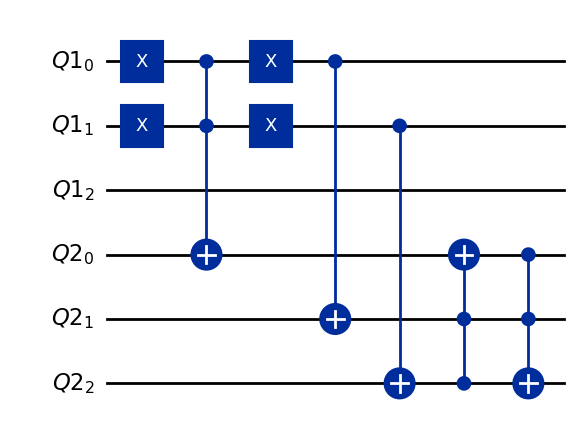

In [10]:
from qiskit.circuit import (QuantumCircuit, QuantumRegister)
qreg1 = QuantumRegister(3,name = 'Q1')
qreg2 = QuantumRegister(3,name = 'Q2')
U = QuantumCircuit(qreg1, qreg2)
U.x(0)
U.x(1)
U.ccx(0,1,3)
U.x(0)
U.x(1)
U.cx(0,4)
U.cx(1,5)
U.ccx(4,5,3)
U.ccx(3,4,5)
U.draw(output="mpl", style="iqp")

The code below can be used to verify that the above circuit does indeed act as $U_f$

In [13]:
from qiskit.circuit import (QuantumCircuit, ClassicalRegister, QuantumRegister)
from qiskit.primitives import StatevectorSampler as Sampler
qreg1 = QuantumRegister(3,name = 'Q1')
qreg2 = QuantumRegister(3,name = 'Q2')
creg = ClassicalRegister(3,name = 'creg')
qc = QuantumCircuit(qreg1, qreg2, creg)
# Change state of input bits here to try different k values
qc.compose(U,inplace=True)
qc.measure(qreg2,creg)
sampler = Sampler()
result = sampler.run([qc]).result()[0]
result.data.creg.get_counts() # Check the state of second register

{'010': 1024}

Now we have $U_f$ for this example, we can construct the rest of the circuit:

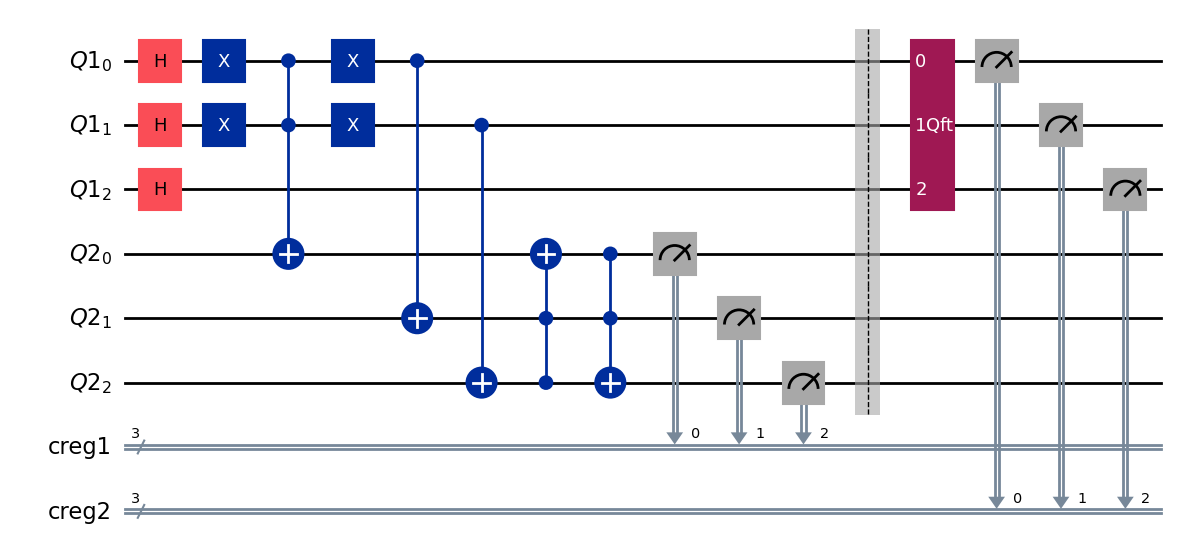

In [271]:
from qiskit.circuit.library import QFTGate
from qiskit.circuit import (QuantumCircuit, ClassicalRegister, QuantumRegister)
qreg1 = QuantumRegister(3,name = 'Q1')
qreg2 = QuantumRegister(3,name = 'Q2')
creg1 = ClassicalRegister(3, name='creg1')
creg2 = ClassicalRegister(3, name='creg2')
qc = QuantumCircuit(qreg1, qreg2, creg1, creg2)
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.ccx(0,1,3)
qc.x(0)
qc.x(1)
qc.cx(0,4)
qc.cx(1,5)
qc.ccx(4,5,3)
qc.ccx(3,4,5)
qc.measure(qreg2,creg1)
qc.barrier()
qc.compose(QFTGate(3), inplace=True)
qc.measure(qreg1,creg2)
qc.draw(output="mpl", style="iqp")

Now we can run this circuit

In [280]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_isa = pm.run(qc)
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000
result = sampler.run([qc_isa]).result()[0]

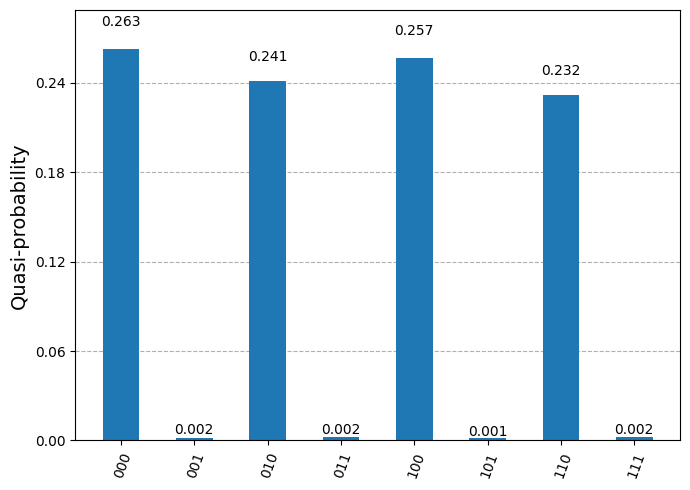

In [281]:
from qiskit.visualization import plot_distribution
qreg2_output_data = result.data.creg2.get_counts()
plot_distribution(qreg2_output_data)

Above is an illustration of the output $c$ for 10,000 runs. As we can see we obtain 4 outcomes with roughly equal probability. These are $c=0,2,4,6$, which are exactly what we expect from the theory.

Now, cancelling $\frac{c}{M}$ in each case excluding $c=0$ we obtain denominators $\tilde r = 4,2,4$ respectively. Hence the algorithm succeeds in half of the runs ($c=2$ & $6$).

## Application to Shor's Algorithm

Given an integer $N$, we wish to find two non-trivial factors.

The first thing to do is check if $N = c^k$ for some integers $c$ & $k$, which can be done in polynomial time.

Failing this, we choose some $a\in\{2,3,...,N-1\}$ coprime to $N$ and compute the period $r$ of $f(k) = a^k \text{ mod } N$

If this $r$ is even, we will have:

$$ a^r \equiv 1 \text{ mod }N $$
$$\Rightarrow (a^{\frac{r}{2}}-1)(a^{\frac{r}{2}}+1) \equiv 0 \text{ mod }N $$

Now, we know that $a^{\frac{r}{2}} \not\equiv 1 \text{ mod }N$ by minimality of $r$ . Hence, either $a^{\frac{r}{2}}+1 \equiv 0 \text{ mod }N$ or $N$ partially divides both $a^{\frac{r}{2}}-1$ & $a^{\frac{r}{2}}+1$.

In the case $a^{\frac{r}{2}}+1 \not\equiv 0 \text{ mod }N$, $N$ will share factors with $a^{\frac{r}{2}}-1$ & $a^{\frac{r}{2}}+1$ and hence $t=\text{gcd}(a^{\frac{r}{2}}±1,N)$ will be a non-trivial factor of $N$.

So after choosing $a$ and computing the period $r$, with some luck $r$ will be even and $a^{\frac{r}{2}}+1 \not\equiv 0 \text{ mod }N$ and we will be able to factorise $N$. Thankfully, the chances of choosing a successful value of $a$ are greater than $\frac{1}{2}$.

### Implementing Period Finding Within Shor's Algorithm

There is a slight technicality when using the period finding algorithm within Shor's algorithm. Previously we had $f:\mathbb{Z}_M\rightarrow\mathbb{Z}_N$ for some integer $M$ and knew that the period $r$ divided $M$. In Shor's algorithm however, we have $f:\mathbb{Z}\rightarrow\mathbb{Z}_N$ without a specified domain. The period finding algorithm relies on a specified value of $M$ and so to use it within Shor's algorithm we must choose some value of $M$. The function $f = a^k \text{ mod }N$ with a restricted domain will not, in general, be periodic since its unrestricted period $r$ may not divide $M$. However, if choose $M$ sufficiently large such that there are enough full periods within the restricted domain $\mathbb{Z}_M$, the period finding algorithm can proceed with negligible additional error.

It turns out that $M=2^m > N^2$ where $m$ is minimal is sufficient for this purpose. Making this choice for $M$, we proceed with the period finding algorithm, obtaining the measurement outcome $c$. This time however, we do not have $\frac{c}{M} = \frac{k_0}{r}$ for some $k_0$. Instead, we have
$$|\frac{c}{M} - \frac{k_0}{r}| < \frac{1}{2N^2}$$
for some $k_0$.
Now, we use the following result:
Any fraction $\frac{k_0}{r}$ satisfying $|\frac{c}{2^m} - \frac{k_0}{r}| < \frac{1}{2r^2}$ must be a _convergent_ of $\frac{c}{2^m}$ and is unique. That is, if
$$\frac{c}{2^m} = \frac{1}{a_1 + \frac{1}{a_2 + ...}}$$
then
$$\frac{k_0}{r} = \frac{1}{a_1 + ... \frac{1}{a_n}}$$
for some $n$ (i.e. a truncation of the continued fraction expression). We will have:
$$|\frac{c}{M} - \frac{k_0}{r}| < \frac{1}{2N^2} < \frac{1}{2r^2}$$
Hence, to we can determine the fraction $\frac{k_0}{r}$ by running through the convergents of $\frac{c}{M}$ until we find the unique one satisfying the above. This can be done in $\text{poly}(\log N)$ time. As with the period finding algorithm, once we have the fraction $\frac{k_0}{r}$ we check if the denominator $\tilde r$ is indeed the period, which will be the case if $k_0$ & $r$ were coprime.